# CC 311 Econometrics — Unit 5
## Lecture 1: Stationarity, Random Walks, AR and MA Models


### Learning goals
By the end of this notebook, you should be able to:

1. Distinguish stationary and non-stationary behaviour visually.
2. Understand why a random walk is non-stationary.
3. See how differencing changes a series.
4. Understand the intuition behind **spurious regression**.
5. Use the **ADF test** as a formal stationarity check.
6. Simulate and interpret **AR(1)** and **MA(1)** processes.




In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import ArmaProcess




## 1. Stationary vs non-stationary: start with intuition

A **stationary** series has broadly stable statistical behaviour over time.

For weak stationarity:

* $E(Y_t) = \mu$ is constant.
* $Var(Y_t) = \sigma^2$ is constant.
* $Cov(Y_t, Y_{t-k})$ depends on the **lag $k$**, not on the calendar date $t$.

We will first create two artificial series so that you can see the difference.


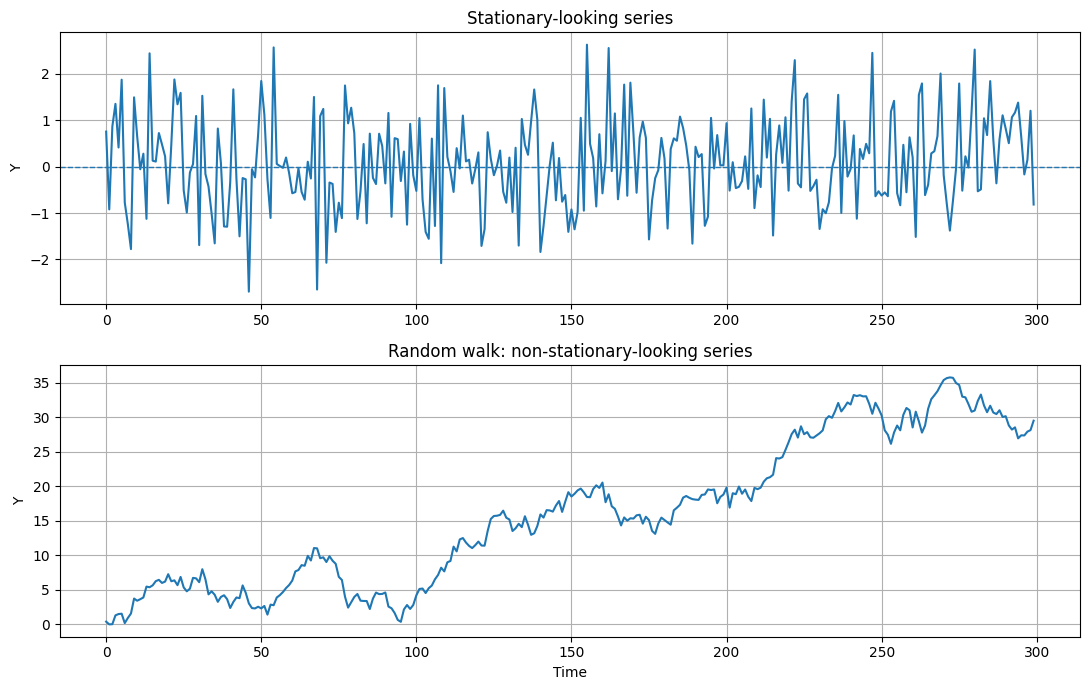

In [ ]:
n = 300

# Stationary-looking process: fluctuations around a stable mean
stationary = np.random.normal(loc=0, scale=1, size=n)

# Non-stationary process: cumulative shocks = random walk
random_walk = np.cumsum(np.random.normal(size=n))

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

axes[0].plot(stationary)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Stationary-looking series")
axes[0].set_ylabel("Y")

axes[1].plot(random_walk)
axes[1].set_title("Random walk: non-stationary-looking series")
axes[1].set_ylabel("Y")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()


### Class questions:

Before going to the next cell:

1. Which series appears to fluctuate around a stable level?
2. Does the random walk have a stable mean?
3. If we estimated its average using the first 50 observations, would we expect the same average in the last 50?
4. What might this mean for forecasting?

**Key idea:** visual inspection does not prove stationarity, but it is an important first step.


## 2. A simple real-data example

We now use the **US quarterly macroeconomic dataset bundled with `statsmodels`**.

We will look at **real GDP** and compare the level with its growth/change.

The purpose is not to claim that one transformation automatically solves every econometric problem. The purpose is to see why we often transform trending macroeconomic variables before modelling their dynamics.


In [ ]:
# Real quarterly macroeconomic data bundled with statsmodels
data = sm.datasets.macrodata.load_pandas().data.copy()

data["year"] = data["year"].astype(int)
data["quarter"] = data["quarter"].astype(int)

data["date"] = pd.PeriodIndex(
    year=data["year"],
    quarter=data["quarter"],
    freq="Q"
).to_timestamp()

data = data.set_index("date")

data[["realgdp", "infl", "unemp"]].tail()


/tmp/ipykernel_1468/1574082762.py:7: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  data["date"] = pd.PeriodIndex(


,realgdp,infl,unemp
date,,,
2008-07-01,13324.600,-3.16,6.0
2008-10-01,13141.920,-8.79,6.9
2009-01-01,12925.410,0.94,8.1
2009-04-01,12901.504,3.37,9.2
2009-07-01,12990.341,3.56,9.6


In [ ]:
data

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
date,,,,,,,,,,,,,,
1959-01-01,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1959-04-01,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
1959-07-01,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
1959-10-01,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
1960-01-01,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2008-07-01,2008,3,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
2008-10-01,2008,4,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
2009-01-01,2009,1,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71


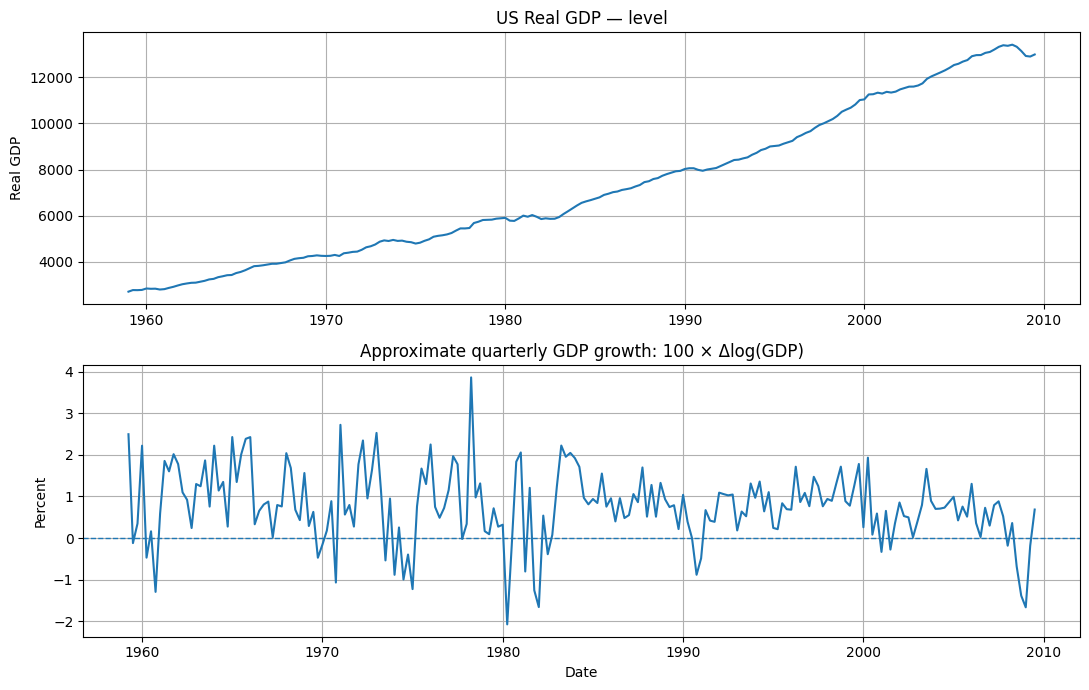

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

axes[0].plot(data.index, data["realgdp"])
axes[0].set_title("US Real GDP — level")
axes[0].set_ylabel("Real GDP")

gdp_growth = 100 * np.log(data["realgdp"]).diff()
axes[1].plot(data.index, gdp_growth)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("Approximate quarterly GDP growth: 100 × Δlog(GDP)")
axes[1].set_ylabel("Percent")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


### Interpretation

The GDP level shows a strong upward movement over time. The transformed growth series fluctuates much more around a comparatively stable level.

**Important:** this graph alone does **not** prove stationarity. It motivates the formal testing step.

This is also a useful place to explain:

> **We are not trying to make data “look nice”. We are trying to model a stable stochastic process.**


## 3. Random walk

A simple random walk is:

$$ Y_t = Y_{t-1} + \varepsilon_t $$

where $\varepsilon_t$ is a new shock at time $t$.


The important intuition is:

**today = yesterday + today's new shock**

Because shocks accumulate, the level does not return to a fixed long-run mean.


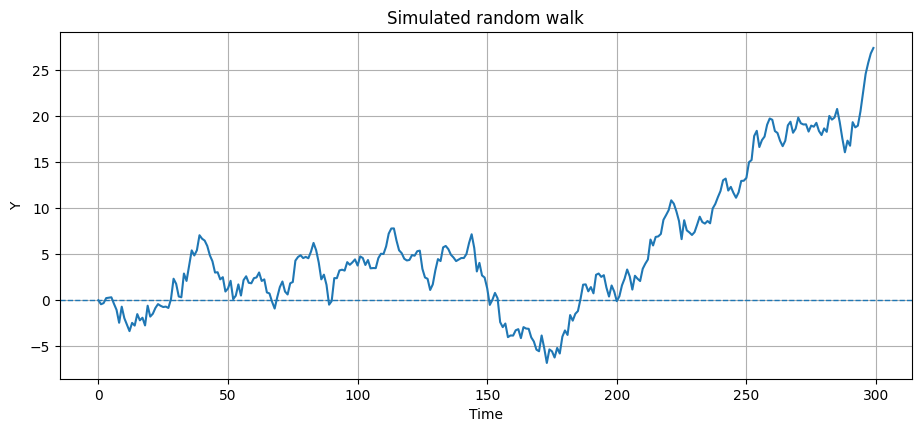

In [ ]:
n = 300
eps = np.random.normal(size=n)

random_walk = np.zeros(n)
for t in range(1, n):
    random_walk[t] = random_walk[t-1] + eps[t]

plt.figure(figsize=(11, 4.5))
plt.plot(random_walk)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Simulated random walk")
plt.xlabel("Time")
plt.ylabel("Y")
plt.show()


## 4. Differencing

The first difference is defined as:

$$ \Delta Y_t = Y_t - Y_{t-1} $$

For a random walk, we know that:

$$ Y_t = Y_{t-1} + \varepsilon_t $$

Therefore, substituting the random walk equation into the first difference gives:

$$ \Delta Y_t = \varepsilon_t $$

So differencing removes the accumulated level component in this simple case, turning a non-stationary random walk into stationary white noise.


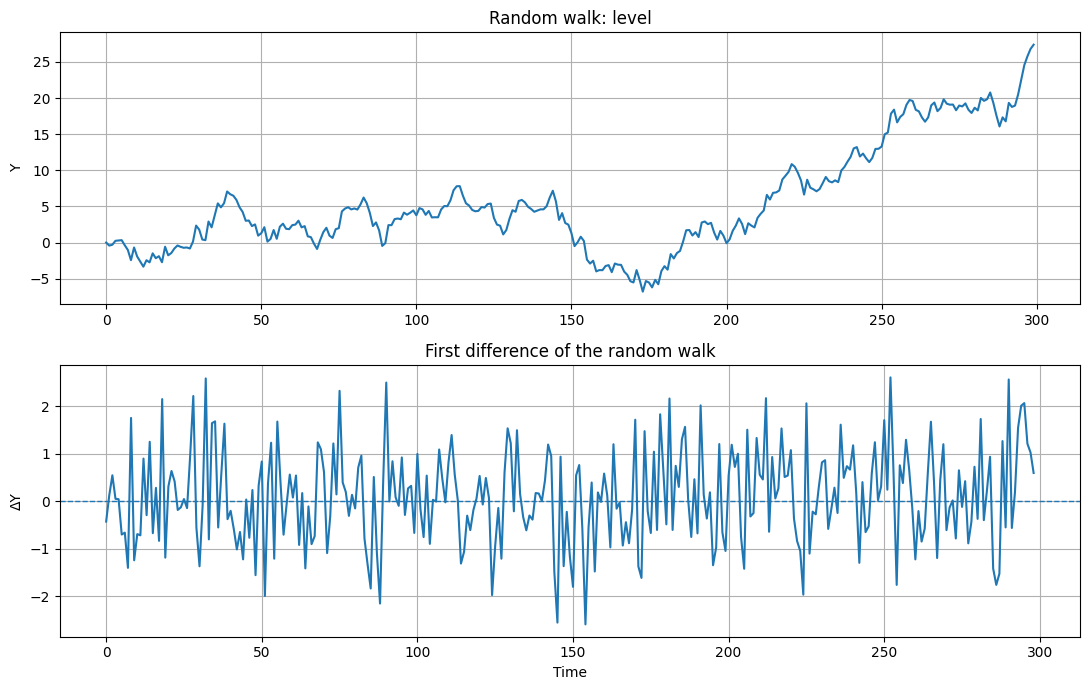

In [ ]:
difference = np.diff(random_walk)

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

axes[0].plot(random_walk)
axes[0].set_title("Random walk: level")
axes[0].set_ylabel("Y")

axes[1].plot(difference)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("First difference of the random walk")
axes[1].set_ylabel("ΔY")
axes[1].set_xlabel("Time")

plt.tight_layout()
plt.show()


### The key message

We changed the question:

- **Level:** “What is the value of the variable?”
- **First difference:** “How much did the variable change from the previous period?”

This is the bridge to **I(0), I(1), ARIMA and cointegration**.


## 5. Spurious regression

Now we create **two completely unrelated random walks**.

There is deliberately **no causal or statistical relationship** between the shocks generating X and Y.

Yet you might find a regression of one on the other, which can look surprisingly convincing because both series wander over time.

(You will need to run the code again and again, since both series are generated randomly, and still you might end up finding a regression with a high R-squared value, suggesting its just matter of chance.)


In [ ]:
n = 300

x = np.cumsum(np.random.normal(size=n))
y = np.cumsum(np.random.normal(size=n))

spurious = pd.DataFrame({"X": x, "Y": y})

X = sm.add_constant(spurious["X"])
model = sm.OLS(spurious["Y"], X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     1078.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):          5.08e-101
Time:                        05:57:31   Log-Likelihood:                -956.02
No. Observations:                 300   AIC:                             1916.
Df Residuals:                     298   BIC:                             1923.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7096      0.523     -8.998      0.0

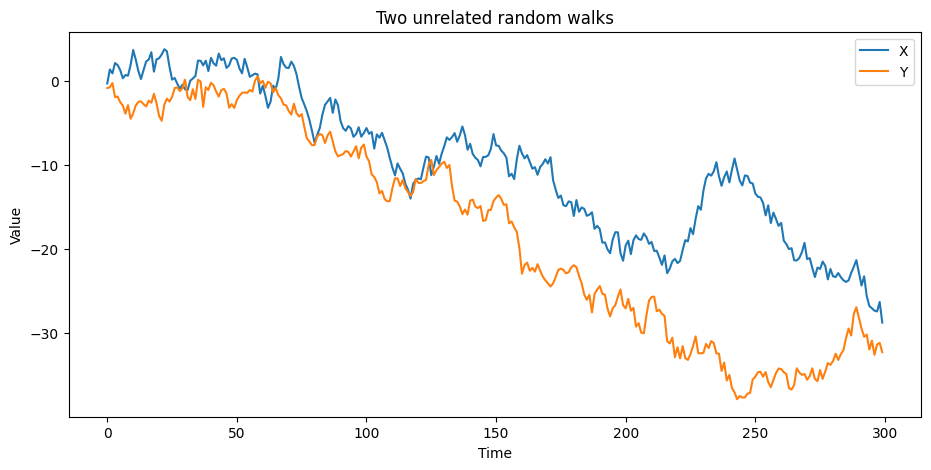

R-squared = 0.783
Coefficient on X = 1.303
p-value on X = 0.00000


In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(spurious["X"], label="X")
plt.plot(spurious["Y"], label="Y")
plt.title("Two unrelated random walks")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

print(f"R-squared = {model.rsquared:.3f}")
print(f"Coefficient on X = {model.params['X']:.3f}")
print(f"p-value on X = {model.pvalues['X']:.5f}")


### Stop here! Try to answer these questions:

> “Did we create X and Y using any relationship?”

**No.** They were generated independently.

Yet the regression may report a large \\(R^2\\) and an apparently significant coefficient.

This is the intuition behind **spurious regression**.

### Why this matters?

A common trend can create the appearance of a relationship even when the underlying processes are unrelated.

That is one major reason stationarity matters in time-series econometrics.


## 6. ADF test: moving from intuition to formal testing

A simplified interpretation of the hypotheses:
* **$H_0$ (Null Hypothesis):** The series has a unit root $\rightarrow$ **Non-stationary**
* **$H_1$ (Alternative Hypothesis):** The series does not have a unit root $\rightarrow$ **Stationary**

Therefore, when interpreting the results:
* **Small $p$-value** ($\le 0.05$) $\rightarrow$ Reject $H_0$ $\rightarrow$ Evidence of **stationarity**.
* **Large $p$-value** ($> 0.05$) $\rightarrow$ Fail to reject $H_0$ $\rightarrow$ The series remains **non-stationary**.

The ADF test does not ask *"Does the graph look stationary?"* Instead, it tests a formal statistical hypothesis regarding the presence of a unit root.

In [ ]:
def adf_report(series, name):

    # Converting to Pandas Series
    series = pd.Series(series).dropna()

    result = adfuller(series, autolag="AIC")

    print(f"--- {name} ---")
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Used lags     : {result[2]}")
    print(f"Observations  : {result[3]}")

    print("Critical values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

    print()

# ADF test for the level series
adf_report(random_walk, "Random walk: level")

# ADF test for the first-differenced series
adf_report(difference, "Random walk: first difference")

--- Random walk: level ---
ADF statistic : 0.6308
p-value       : 0.9884
Used lags     : 0
Observations  : 299
Critical values:
  1%: -3.4524
  5%: -2.8713
  10%: -2.5719

--- Random walk: first difference ---
ADF statistic : -8.7459
p-value       : 0.0000
Used lags     : 2
Observations  : 296
Critical values:
  1%: -3.4526
  5%: -2.8714
  10%: -2.5720



/tmp/ipykernel_1468/2958180394.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag="AIC")
/tmp/ipykernel_1468/2958180394.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series, autolag="AIC")


### How to explain the output

Do **not** memorise “ADF p-value < 0.05 = stationary” without the hypotheses.

Always begin with:

**H₀ = unit root / non-stationarity**

Then interpret the p-value relative to that null.

Also, ADF results depend on the specification (constant, trend, lag selection), so the test is evidence—not a magic button. (You can read more about it in your own time, its not covered here).


## 7. AR(1): the series remembers its own past

The **AR(1)** model is defined as:

$$ Y_t = c + \phi Y_{t-1} + \varepsilon_t $$

The key feature is that the current value depends directly on its **own previous value**.

* **$\phi$** measures the level of persistence.
* A **larger positive $\phi$** generally indicates stronger persistence (the series takes longer to return to its baseline after a shock).
* For a standard AR(1) process to be **stationary** around its long-run mean, the parameter must satisfy **$|\phi| < 1$** (retaining no unit root).



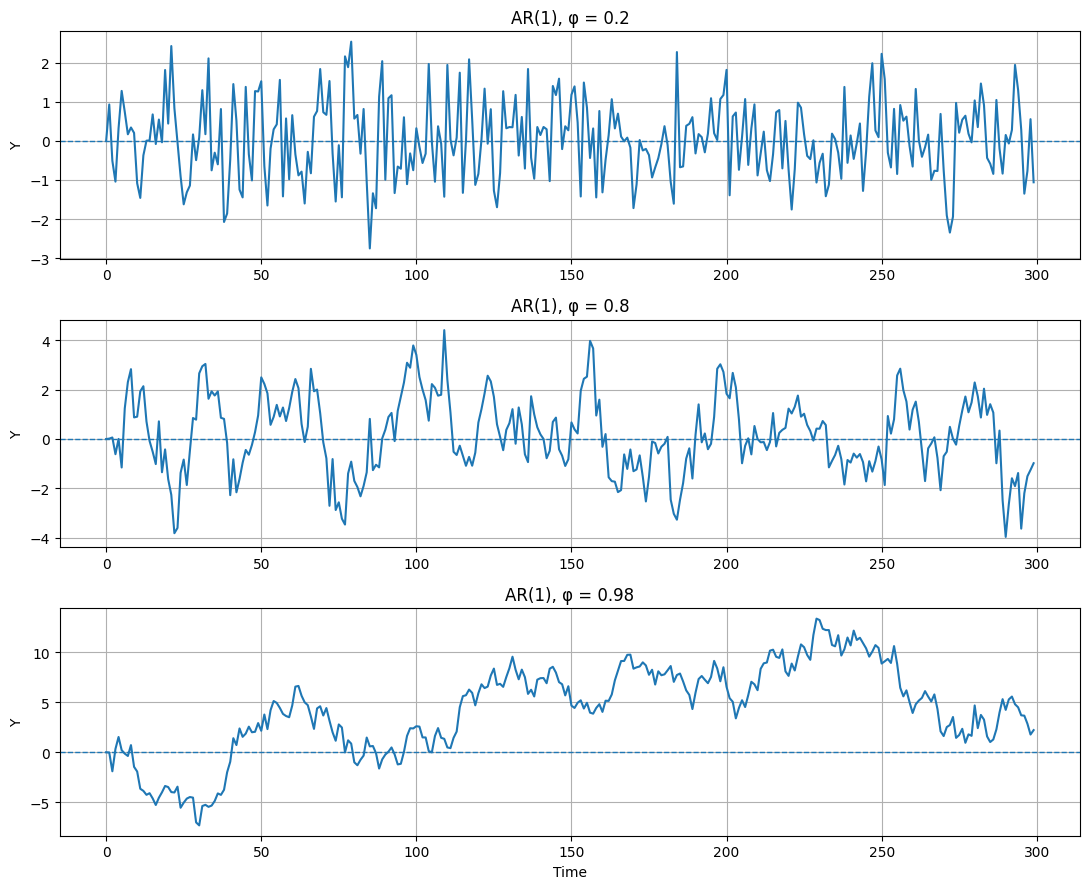

In [ ]:
def simulate_ar1(phi, n=300):
    eps = np.random.normal(size=n)
    y = np.zeros(n)
    for t in range(1, n):
        y[t] = phi * y[t-1] + eps[t]
    return y

phis = [0.2, 0.8, 0.98]

fig, axes = plt.subplots(3, 1, figsize=(11, 9))

for ax, phi in zip(axes, phis):
    y = simulate_ar1(phi)
    ax.plot(y)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"AR(1), φ = {phi}")
    ax.set_ylabel("Y")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


### What you should notice?

As \\(\phi\\) gets closer to 1:

- shocks persist for longer;
- the series shows stronger memory;
- observations are more strongly related to their recent past.

This is a useful visual bridge to **autocorrelation** and later **ACF/PACF**.


## 8. MA(1): the series remembers shocks

The **MA(1)** model is defined as:

$$ Y_t = \mu + \varepsilon_t + \theta\varepsilon_{t-1} $$

The key differences in mechanics:
* **AR (Autoregressive)** $\rightarrow$ Depends directly on **past values of $Y$** (internal momentum).
* **MA (Moving Average)** $\rightarrow$ Depends directly on **past shocks/errors $\varepsilon$** (fading external echoes).

We can simulate an MA(1) process and vary the parameter **$\theta$** to see how quickly shocks dissipate.



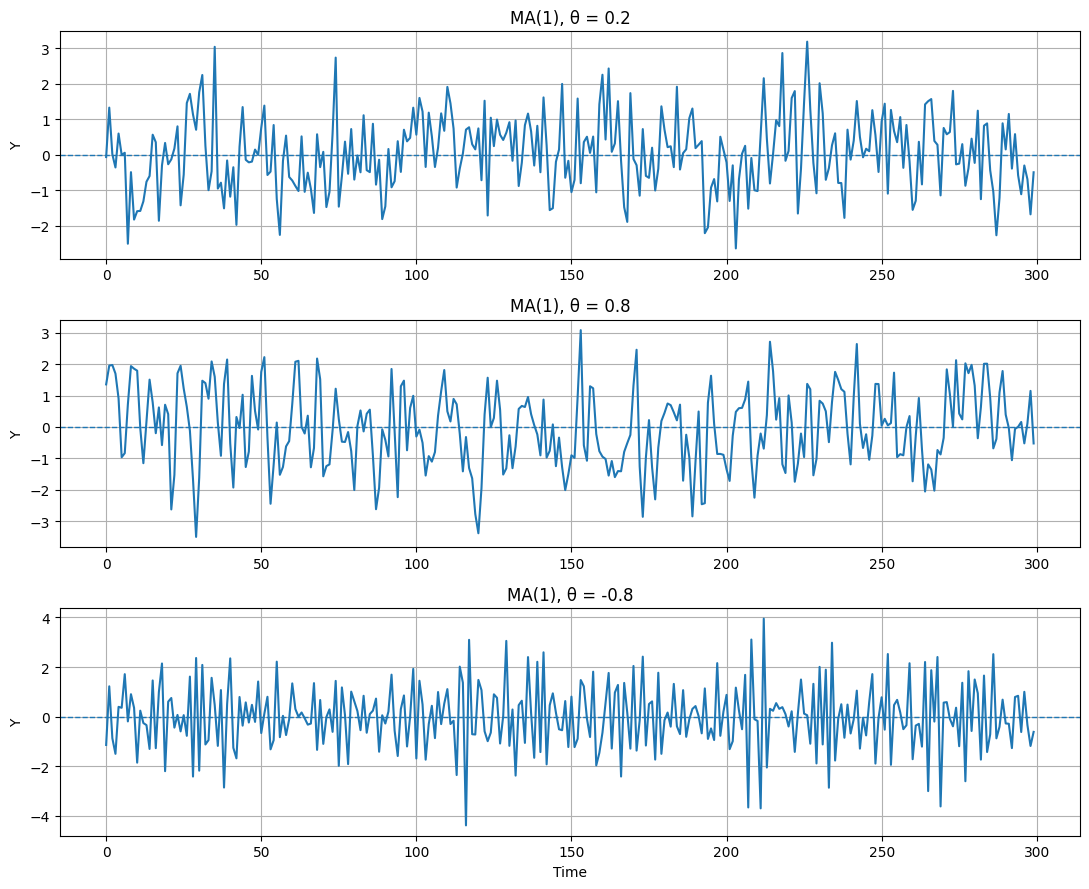

In [ ]:
def simulate_ma1(theta, n=300):
    eps = np.random.normal(size=n+1)
    y = np.zeros(n)
    for t in range(n):
        y[t] = eps[t+1] + theta * eps[t]
    return y

thetas = [0.2, 0.8, -0.8]

fig, axes = plt.subplots(3, 1, figsize=(11, 9))

for ax, theta in zip(axes, thetas):
    y = simulate_ma1(theta)
    ax.plot(y)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"MA(1), θ = {theta}")
    ax.set_ylabel("Y")

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()


## 9. AR vs MA — the one-line distinction


| Model | Current value depends on | Intuition |
| :--- | :--- | :--- |
| **AR** | Past values $Y_{t-1}, Y_{t-2}, \dots$ | Internal momentum (memory of the series) |
| **MA** | Past shocks $\varepsilon_{t-1}, \varepsilon_{t-2}, \dots$ | External impacts (memory of the shocks) |

### Memory Aid

* **AR** $\rightarrow$ *“I remember my past values.”*
* **MA** $\rightarrow$ *“I remember past shocks.”*



## 10. Optional extension: inspect autocorrelation

This is a preview of what comes next.

The **ACF** measures correlation between a series and its own lagged values.

We will use ACF/PACF more systematically when choosing ARIMA specifications.


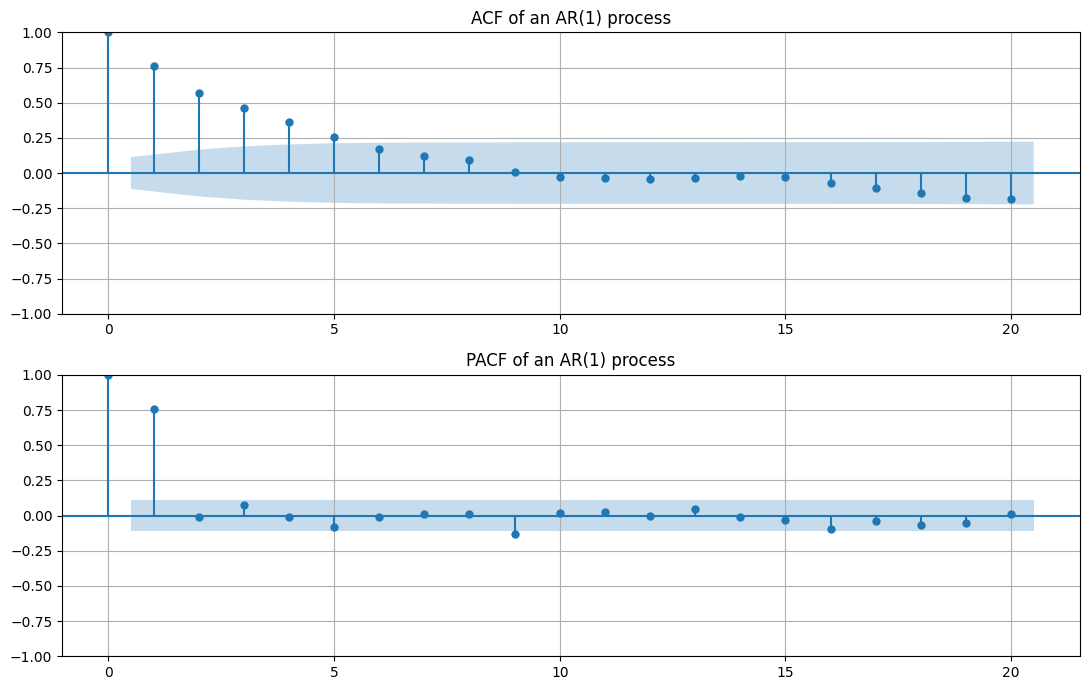

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ar_series = pd.Series(simulate_ar1(0.8, 300))

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
plot_acf(ar_series, lags=20, ax=axes[0])
axes[0].set_title("ACF of an AR(1) process")

plot_pacf(ar_series, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of an AR(1) process")

plt.tight_layout()
plt.show()


### ⚠️ Note on Workflow: Simulation vs. Real World

* **In this classroom simulation:** We start with a known **Model** $\rightarrow$ generate the **Series** $\rightarrow$ verify the **Plots**. This teaches us what the theoretical "fingerprints" look like.
* **In real-world data science:** You start with an unknown **Series** $\rightarrow$ compute the **Plots** $\rightarrow$ discover the fingerprints $\rightarrow$ select the correct **Model** specifications ($p, q$).


## 11. End-of-lecture recap

### Conceptual chain

**Time series → stationarity → non-stationarity → random walk → differencing**

and

**Past values → AR**

**Past shocks → MA**

### Next lecture

We can build from here to:

1. ARMA models
2. ACF and PACF
3. ARIMA
4. ARIMA forecasting
5. Then we will connect this to the syllabus requirement on **cointegration and error-correction mechanisms**.

###  Closing question

> If two variables are both I(1), does that automatically mean we cannot study their long-run relationship?


